<a href="https://colab.research.google.com/github/Mahian-Hoq/ml-notebooks-from-scratch/blob/main/Models_performance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Import all necessary libraries here

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#Prep tools
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score,accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import OneHotEncoder, PolynomialFeatures, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

#Models
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.svm import SVC, SVR
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
from google.colab import drive
drive.mount('/content/MyDrive')

Mounted at /content/MyDrive


# 🔵 Regression Task


## Dataset Loading and Understanding


In [ ]:
# TODO: Load regression dataset
ins_df = pd.read_csv('/content/MyDrive/MyDrive/Data/Phitron_data/CSV_data/Assignment-3/insurance.csv')

display(ins_df.shape)
display(ins_df.columns)

ins_df.head()

(1338, 7)

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


### Here in this dataset the target is charges.

In the prediction we have to predict **charges** depending on age, sex, bmi, children, smoker, region.

In [ ]:
num_features = ['age', 'bmi', 'children']
cat_features = ['sex', 'smoker', 'region']
target = 'charges'

## Exploratory Data Analysis (EDA)


In [ ]:
# Perform EDA
ins_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [ ]:
ins_df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1338.0,39.207025,14.049960,18.0000,27.00000,39.000,51.000000,64.00000
bmi,1338.0,30.663397,6.098187,15.9600,26.29625,30.400,34.693750,53.13000
children,1338.0,1.094918,1.205493,0.0000,0.00000,1.000,2.000000,5.00000
charges,1338.0,13270.422265,12110.011237,1121.8739,4740.28715,9382.033,16639.912515,63770.42801


> Here we can see the age and bmi features are evenly distributed.

> As the sex, smoker and region features are catagorial. Have to encode them.

In [ ]:
ins_df['region'].unique()

array(['southwest', 'southeast', 'northwest', 'northeast'], dtype=object)

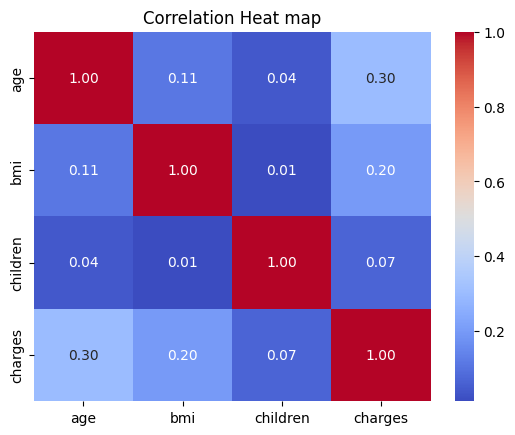

In [ ]:
# Correlation Heat Map
sns.heatmap(ins_df[num_features + [target]].corr(), annot = True, fmt = '.2f', cmap = 'coolwarm')
plt.title('Correlation Heat map')
plt.show()

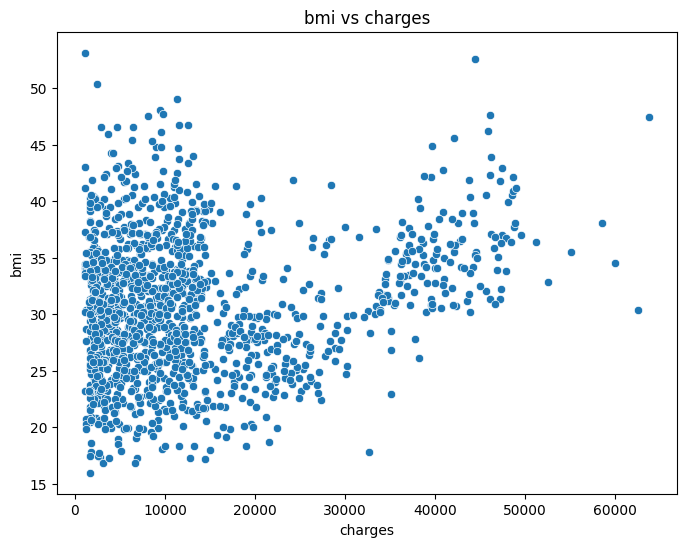

In [ ]:
plt.figure(figsize= (8,6))
sns.scatterplot(data = ins_df, x= 'charges', y = 'bmi')
plt.xlabel('charges')
plt.ylabel('bmi')
plt.title('bmi vs charges')
plt.show()

## Feature Preparation


In [ ]:
ins_df_enc = pd.get_dummies(
    ins_df,
    columns=cat_features,
    drop_first= True,
    dtype=int
)

ins_df_enc.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,0,1,0,0,1
1,18,33.770,1,1725.55230,1,0,0,1,0
2,28,33.000,3,4449.46200,1,0,0,1,0
3,33,22.705,0,21984.47061,1,0,1,0,0
4,32,28.880,0,3866.85520,1,0,1,0,0


In [ ]:
X = ins_df_enc.drop('charges', axis = 1) # Predictors
y = ins_df['charges'] # Target

X.shape, y.shape

((1338, 8), (1338,))

In [ ]:
# Prepare features
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.75, random_state=42)

X_train.shape, X_test.shape

((1003, 8), (335, 8))

## Multiple Linear Regression


In [ ]:
# TODO: Multiple Linear Regression
mlr = LinearRegression()
mlr.fit(X_train, y_train)

LinearRegression()

In [ ]:
y_prob_mlr = mlr.predict(X_test)

rmse_mlr = np.sqrt(mean_squared_error(y_test, y_prob_mlr))
mae_mlr = mean_absolute_error(y_test, y_prob_mlr)
r2_mlr = r2_score(y_test, y_prob_mlr)
print('RMSE : ',rmse_mlr,'\nMAE : ', mae_mlr, '\nR2 : ', r2_mlr)

RMSE :  5926.023602394469 
MAE :  4243.654116653137 
R2 :  0.7672642952734356


## Polynomial Regression


In [ ]:
ins_df_enc.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,0,1,0,0,1
1,18,33.770,1,1725.55230,1,0,0,1,0
2,28,33.000,3,4449.46200,1,0,0,1,0
3,33,22.705,0,21984.47061,1,0,1,0,0
4,32,28.880,0,3866.85520,1,0,1,0,0


In [ ]:
# Polynomial Regression
digs = [2,3,4]
poly_f = ['age','bmi']
res = []
for dig in digs:
  prep = ColumnTransformer([
      ('poly', PolynomialFeatures(dig, include_bias=False), poly_f),
      ('n', 'passthrough', list(ins_df_enc.columns.drop(['age','bmi', 'charges'])))
  ])
  model = Pipeline([
      ('features', prep),
      ('mlr', LinearRegression())
  ])

  model.fit(X_train, y_train)

  res.append({
      'degree': dig,
      'rmse' : np.sqrt(mean_squared_error(y_test, y_prob_mlr)),
      'mae': mean_absolute_error(y_test, y_prob_mlr),
      'r2_score' : r2_score(y_test, y_prob_mlr)
  })

res_df = pd.DataFrame(res)
res_df

,degree,rmse,mae,r2_score
0,2,5926.023602,4243.654117,0.767264
1,3,5926.023602,4243.654117,0.767264
2,4,5926.023602,4243.654117,0.767264


###Comparison

There is no changes. Cause the features not for polynomial. They ment to be separated.

## Support Vector Regression


In [ ]:
#Underline Model
model = Pipeline([
    ('scaler', StandardScaler()),
    ('svr', SVR(kernel='rbf'))
])

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print('MAE:', mean_absolute_error(y_test, y_pred))
print('RMSE:', mean_squared_error(y_test, y_pred) ** 0.5)
print('R²:', r2_score(y_test, y_pred))

MAE: 8483.964170106703
RMSE: 12843.096424902353
R²: -0.0931399027291584


In [ ]:
# TODO: Support Vector Regression
param = [
    {
        'svr__C' : [10000,50000, 75000],
        'svr__gamma': ['scale', 0.1, 0.5,1],
        'svr__epsilon' : [0.1]

    }
]

grid = GridSearchCV(
    model,
    param,
    cv = 5,
    scoring='neg_root_mean_squared_error',
    n_jobs = -1
)

grid.fit(X_train, y_train)

print(grid.best_params_)
print(grid.best_score_)

{'svr__C': 50000, 'svr__epsilon': 0.1, 'svr__gamma': 0.1}
-4955.748298162134


In [ ]:
best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)

print('RMSE:', mean_squared_error(y_test, y_pred) ** 0.5)
print('MAE:', mean_absolute_error(y_test, y_pred))
print('R²:', r2_score(y_test, y_pred))

RMSE: 4760.779866459956
MAE: 1806.9085017663754
R²: 0.8497922079370123


###Comparison

The svr with rbf is showing less RMSE and MAE with increasing R2 score. From MLR and Polynomial Regression this model showed a great performance.

###Justification for RBF

as the bmi age and other features are far more complex a very tight regression pip was useful in this case. Also the other kernels like linear and poly is already tried in MLR and PLR. Thats why RBF is the justified kernel for this dataset.

## Random Forest Regressor


In [ ]:
# TODO: Random Forest Regressor
#Base model
model = Pipeline([
    ('scaler', StandardScaler()),
    ('rnd', RandomForestRegressor(random_state=42))
])

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print('RMSE : ', (mean_squared_error(y_test, y_pred)) ** .5)
print('MAE : ',mean_absolute_error(y_test, y_pred))
print('R2 : ', r2_score(y_test, y_pred))

RMSE :  4790.620738299574
MAE :  2637.351257640174
R2 :  0.8479032824381821


In [ ]:
param = {
    'rnd__n_estimators' : [300,325, 350],
    'rnd__max_depth' : [10],
    'rnd__min_samples_split' : [5,7,8,9],
    'rnd__max_features' : ['log2']
}

In [ ]:
grid = GridSearchCV(
    model,
    param,
    cv = 5,
    scoring = 'neg_root_mean_squared_error',
    n_jobs = -1
)

grid.fit(X_train, y_train)

print(grid.best_params_)
print(grid.best_score_)

{'rnd__max_depth': 10, 'rnd__max_features': 'log2', 'rnd__min_samples_split': 7, 'rnd__n_estimators': 300}
-4727.2425226330415


In [ ]:
best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)

print('RMSE:', mean_squared_error(y_test, y_pred) ** 0.5)
print('MAE:', mean_absolute_error(y_test, y_pred))
print('R²:', r2_score(y_test, y_pred))

RMSE: 4560.931433063164
MAE: 2675.102948867174
R²: 0.8621383894519399


###Comparison

> If we give priority to overall redictive fit and avoiding large mistake, Random Forest Regressor was the good model. Cause this model has stronger RMSE and R2 score

> If we priotize prediction error then the SVR is good, cause the lower MAE

In overall result and after thinking about the dataset and its perpose I think the insurance needed to low on large prediction mistakes. So here we should chose for **Random Forest Regressor**

In [ ]:
# BEST MODEL OVERALL with best parameters
SVR_rbf_model = Pipeline([
    ('scaler', StandardScaler()),
    ('rnd', RandomForestRegressor(n_estimators=300, max_depth=10, min_samples_split= 7, max_features='log2', random_state = 42))
])

SVR_rbf_model.fit(X_train, y_train)

y_pred = SVR_rbf_model.predict(X_test)

print('RMSE:', mean_squared_error(y_test, y_pred) ** 0.5)
print('MAE:', mean_absolute_error(y_test, y_pred))
print('R²:', r2_score(y_test, y_pred))

RMSE: 4560.931433063164
MAE: 2675.102948867174
R²: 0.8621383894519399


# 🟠 Classification


## Dataset Understanding


In [ ]:
# Load classification dataset
loan_df = pd.read_csv('/content/MyDrive/MyDrive/Data/Phitron_data/CSV_data/Assignment-3/loan_data.csv')

loan_df.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


In [ ]:
loan_df['loan_status'].value_counts()

,count
loan_status,
0,35000
1,10000


###Comment on loan_status

> Here we can see a huge imbalance. The number of status 1 is too low. We have to evenly distribute this 1 status in train test split for this.

##  Exploratory Data Analysis



<Axes: xlabel='loan_status', ylabel='count'>

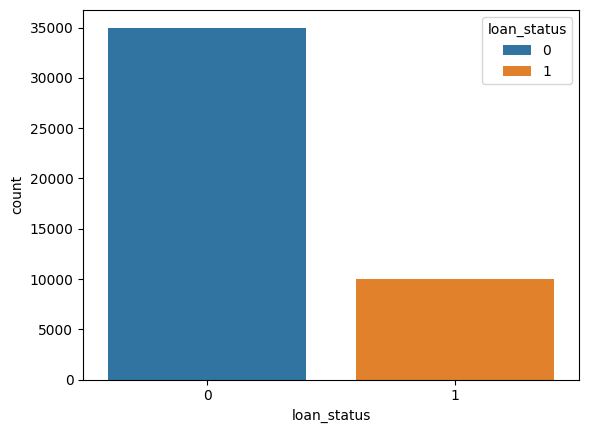

In [ ]:
# Classification EDA
sns.countplot(data = loan_df, x = 'loan_status', hue = 'loan_status')
plt.title('')

Text(0.5, 1.0, 'Countplot of previous_loan_defaults_on_file with loan_status')

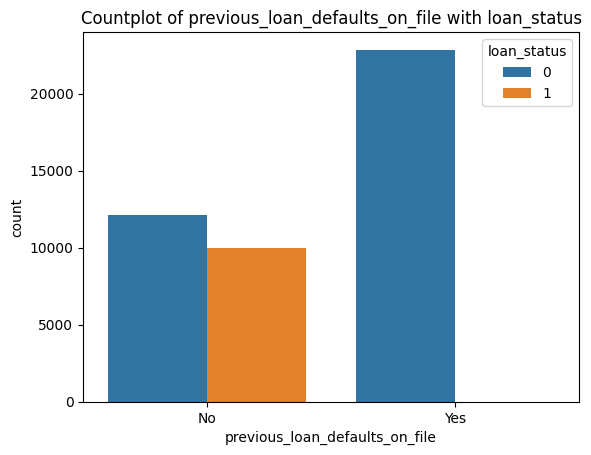

In [ ]:
sns.countplot(data = loan_df, x= 'previous_loan_defaults_on_file', hue = 'loan_status')
plt.title('Countplot of previous_loan_defaults_on_file with loan_status')

## Feature Preparation




In [ ]:
loan_df_enc = pd.get_dummies(data = loan_df, drop_first=True, dtype = int)
loan_df_enc.head()
#If we scale now befor spliting data leakage will happen

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status,person_gender_male,...,person_education_Master,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,previous_loan_defaults_on_file_Yes
0,22.0,71948.0,0,35000.0,16.02,0.49,3.0,561,1,0,...,1,0,0,1,0,0,0,1,0,0
1,21.0,12282.0,0,1000.0,11.14,0.08,2.0,504,0,0,...,0,0,1,0,1,0,0,0,0,1
2,25.0,12438.0,3,5500.0,12.87,0.44,3.0,635,1,0,...,0,0,0,0,0,0,1,0,0,0
3,23.0,79753.0,0,35000.0,15.23,0.44,2.0,675,1,0,...,0,0,0,1,0,0,1,0,0,0
4,24.0,66135.0,1,35000.0,14.27,0.53,4.0,586,1,1,...,1,0,0,1,0,0,1,0,0,0


In [ ]:
X = loan_df_enc.drop('loan_status', axis = 1)
y = loan_df_enc['loan_status']


X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.25, random_state=42, stratify=y)

#Scaling
scaler = StandardScaler()
X_train_scl = scaler.fit_transform(X_train)
X_test_scl = scaler.transform(X_test)

X_train.shape, X_test.shape

((33750, 22), (11250, 22))

In [ ]:
#a function for telling all scores
def cls_scores(y_true,y_predict, model_name):
  print(model_name, '\nAccuracy :', accuracy_score(y_true, y_predict))
  print('Precision : ', precision_score(y_true, y_predict))
  print('Recall : ', recall_score(y_true, y_predict))
  print(' \t F1 Score : ', f1_score(y_true, y_predict))
  print('--'*30)

## Logistic Regression with L2



in this loan dataset a loan company may highly demotivated to lend loan on a non combatent applicant. If so then we can focus on precision. But In kaggle there is no mentioning about where to focus on. By manupulating the C we can get far more greate precision. For now lets stay on the middle. We just need a good balance in precision and recall. So I will use f1 score as the main scoring method.

In [ ]:
# Logistic Regression
params = {
    'max_iter': [100,200,300,500],
    'C' : [0.001,0.01, 0.1, 1, 1.1]
}

grid = GridSearchCV(
    LogisticRegression(),
    params,
    cv = 5,
    scoring = 'f1',
    n_jobs = -1

)

grid.fit(X_train_scl, y_train)

print(grid.best_params_)
print(grid.best_score_)

{'C': 1, 'max_iter': 100}
0.7586933850875404


In [ ]:
y_pred = grid.best_estimator_.predict(X_test_scl)
cls_scores(y_test, y_pred, 'Logistic Regression')

Logistic Regression 
Accuracy : 0.9
Precision :  0.791437049597287
Recall :  0.7468
 	 F1 Score :  0.7684708787816423
------------------------------------------------------------


In [ ]:
y_proba = grid.best_estimator_.predict_proba(X_test_scl)[:,1]

thrs = np.linspace(0.1,0.9,9)

for thr in thrs:
  y_pred_t = (y_proba >=thr)#.astype(int)
  cls_scores(y_test, y_pred_t, 'Threshold :'+ str(thr))

Threshold :0.1 
Accuracy : 0.8115555555555556
Precision :  0.5424296560964716
Recall :  0.9716
 	 F1 Score :  0.6961880194898251
------------------------------------------------------------
Threshold :0.2 
Accuracy : 0.8554666666666667
Precision :  0.6164712153518124
Recall :  0.9252
 	 F1 Score :  0.7399232245681382
------------------------------------------------------------
Threshold :0.30000000000000004 
Accuracy : 0.8811555555555556
Precision :  0.6797527047913446
Recall :  0.8796
 	 F1 Score :  0.766870095902354
------------------------------------------------------------
Threshold :0.4 
Accuracy : 0.8947555555555555
Precision :  0.7372025955299207
Recall :  0.818
 	 F1 Score :  0.7755024649222602
------------------------------------------------------------
Threshold :0.5 
Accuracy : 0.9
Precision :  0.791437049597287
Recall :  0.7468
 	 F1 Score :  0.7684708787816423
------------------------------------------------------------
Threshold :0.6 
Accuracy : 0.9000888888888889
Precis

So in this **Logistic Regression** model with C value 1, and threshold as 0.5 we got the best f1 score. Means best balanced precision and recall for Logistic Regression

## Support Vector Machine


In [ ]:
# SVM Classification
params = {
    'C' : [0.01, 0.1, 1],
    'gamma' : ['scale',0.1,1]
}

grid = GridSearchCV(
    SVC(kernel = 'rbf'),
    params,
    cv = 5,
    scoring = 'f1',
    n_jobs = -1

)

grid.fit(X_train_scl, y_train)

print(grid.best_params_)
print(grid.best_score_)
y_pred = grid.best_estimator_.predict(X_test_scl)
cls_scores(y_test, y_pred, 'SVC with rbf')

{'C': 1, 'gamma': 'scale'}
0.7899823395536852
SVC with rbf 
Accuracy : 0.9149333333333334
Precision :  0.8498866213151928
Recall :  0.7496
 	 F1 Score :  0.7965993623804464
------------------------------------------------------------


In [ ]:
params = {
    'C' : [0.001,0.01, 0.1, 1]
}

grid = GridSearchCV(
    SVC(kernel = 'linear'),
    params,
    cv = 5,
    scoring = 'f1',
    n_jobs = -1

)

grid.fit(X_train_scl, y_train)

print(grid.best_params_)
print(grid.best_score_)
y_pred = grid.best_estimator_.predict(X_test_scl)
cls_scores(y_test, y_pred, 'SVC with linear')

{'C': 0.1}
0.758367448011394
SVC with linear 
Accuracy : 0.8998222222222222
Precision :  0.793752674368849
Recall :  0.742
 	 F1 Score :  0.7670043415340086
------------------------------------------------------------


In these three models we get the Recall almost similar. but The Precision is more higher in SVC rbf. So from these three models,

The Best performer is : SVC with rbf kernel

## Naive Bayes



In [ ]:
loan_df_enc.head()

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status,person_gender_male,...,person_education_Master,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,previous_loan_defaults_on_file_Yes
0,22.0,71948.0,0,35000.0,16.02,0.49,3.0,561,1,0,...,1,0,0,1,0,0,0,1,0,0
1,21.0,12282.0,0,1000.0,11.14,0.08,2.0,504,0,0,...,0,0,1,0,1,0,0,0,0,1
2,25.0,12438.0,3,5500.0,12.87,0.44,3.0,635,1,0,...,0,0,0,0,0,0,1,0,0,0
3,23.0,79753.0,0,35000.0,15.23,0.44,2.0,675,1,0,...,0,0,0,1,0,0,1,0,0,0
4,24.0,66135.0,1,35000.0,14.27,0.53,4.0,586,1,1,...,1,0,0,1,0,0,1,0,0,0


In [ ]:
# Gaussian Naive Bayes
gnb = GaussianNB(var_smoothing=1e-4)

gnb.fit(X_train_scl, y_train)
y_pred = gnb.predict(X_test_scl)
cls_scores(y_test, y_pred, 'Gaussian Naive Bayes')

Gaussian Naive Bayes 
Accuracy : 0.7638222222222222
Precision :  0.4844029405920922
Recall :  0.9752
 	 F1 Score :  0.6472852781096509
------------------------------------------------------------


###Comparison

Here we can see that from previous models this GaussianNB has a higher recall but the precision is too much low. Mean the model has predicted 1 for too many customers. among them one part is correct which indicates higher recall, but many of the 1 predicted are incorrect, indicating precision.

In summery this model was not very good at generalizing the patterns of the dataset.

## K-Nearest Neighbors


In [ ]:
# KNN
ks = [90,100,103,104,105,106]
res = []

for k in ks:
  model = KNeighborsClassifier(
      n_neighbors = k,
      weights = 'uniform',
      metric= 'minkowski',
      p = 1
  )

  model.fit(X_train_scl, y_train)
  y_pred = model.predict(X_test_scl)

  res.append({
      'K':k,
      'Accuracy': accuracy_score(y_test, y_pred),
      'Precision': precision_score(y_test, y_pred),
      'Recall': recall_score(y_test, y_pred),
      'F1': f1_score(y_test, y_pred)
  })

res_df = pd.DataFrame(res)
res_df

,K,Accuracy,Precision,Recall,F1
0,90,0.895111,0.899033,0.5948,0.715936
1,100,0.896533,0.911330,0.5920,0.717750
2,103,0.897333,0.909312,0.5976,0.721217
3,104,0.896800,0.914551,0.5908,0.717861
4,105,0.897511,0.911423,0.5968,0.721296
5,106,0.896622,0.916511,0.5884,0.716687


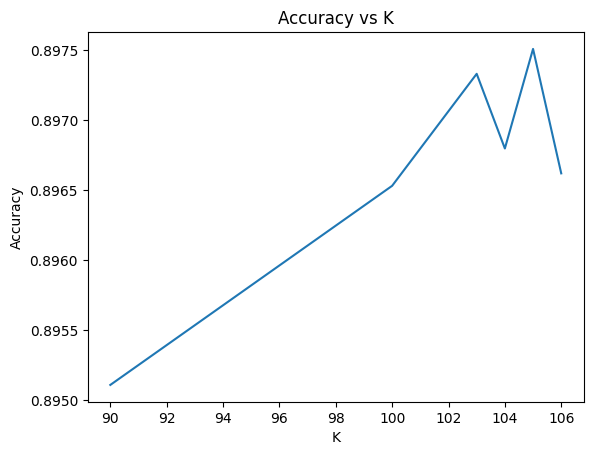

In [ ]:
plt.plot(res_df['K'], res_df['Accuracy'])
plt.title('Accuracy vs K')
plt.xlabel('K')
plt.ylabel('Accuracy')
plt.show()

## Random Forest Classifier


In [ ]:
# Random Forest Classifier
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt']
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state = 42),
    param_grid,
    cv=5,
    scoring='precision',
    n_jobs=-1
)

grid_rf.fit(X_train_scl, y_train)

print(grid_rf.best_params_)
print(grid_rf.best_score_)

{'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
0.9127819456272646


In [ ]:
y_pred_rf = grid_rf.best_estimator_.predict(X_test_scl)

cls_scores(y_test, y_pred_rf,'Random Forest Classification')

Random Forest Classification 
Accuracy : 0.9220444444444444
Precision :  0.9150895140664962
Recall :  0.7156
 	 F1 Score :  0.8031425364758699
------------------------------------------------------------


In [ ]:
importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': grid_rf.best_estimator_.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

                               Feature  Importance
21  previous_loan_defaults_on_file_Yes    0.324804
5                  loan_percent_income    0.209794
4                        loan_int_rate    0.157132
1                        person_income    0.110976
15          person_home_ownership_RENT    0.082541
3                            loan_amnt    0.034755
7                         credit_score    0.017842
14           person_home_ownership_OWN    0.012771
20                 loan_intent_VENTURE    0.008279
0                           person_age    0.006915
17         loan_intent_HOMEIMPROVEMENT    0.005963
16               loan_intent_EDUCATION    0.005425
18                 loan_intent_MEDICAL    0.005423
2                       person_emp_exp    0.005355
6           cb_person_cred_hist_length    0.004825
19                loan_intent_PERSONAL    0.002518
11        person_education_High School    0.001038
8                   person_gender_male    0.000949
9            person_education_B

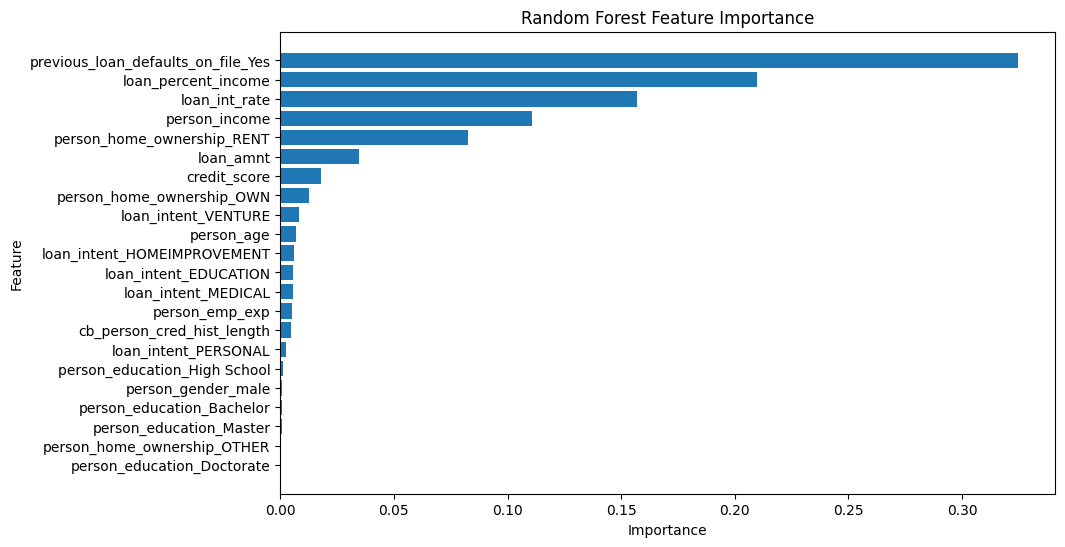

In [ ]:
plt.figure(figsize=(10, 6))

plt.barh(
    importance['Feature'],
    importance['Importance']
)

plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Random Forest Feature Importance')
plt.gca().invert_yaxis()

plt.show()

# Final Reflection




> If we give priority to overall redictive fit and avoiding large mistake, Random Forest Regressor was the good model. Cause this model has stronger RMSE and R2 score

> If we priotize prediction error then the SVR is good, cause the lower MAE

In overall result and after thinking about the dataset and its perpose I think the insurance needed to low on large prediction mistakes. So here we should chose for **Random Forest Regressor**

**Random Forest Classification** was the best-performing model because it achieved the highest F1 score, providing the best balance between precision and recall among the tested models.

> A bank could use the Random Forest model as an automated loan-approval screening system to predict whether applicants are likely to qualify for a loan.